In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = '../data'


In [2]:
# Load Detailed Regular Season Results
m_reg_detailed = pd.read_csv(f'{DATA_DIR}/MRegularSeasonDetailedResults.csv')

# Calculate Possessions for both Winning and Losing teams
# A common formula for basketball possessions is: FGA - OR + TO + 0.475 * FTA
w_pos = m_reg_detailed['WFGA'] - m_reg_detailed['WOR'] + m_reg_detailed['WTO'] + 0.475 * m_reg_detailed['WFTA']
l_pos = m_reg_detailed['LFGA'] - m_reg_detailed['LOR'] + m_reg_detailed['LTO'] + 0.475 * m_reg_detailed['LFTA']

# We can average them for a game possession estimate
m_reg_detailed['Possessions'] = (w_pos + l_pos) / 2

# Calculate Offensive and Defensive Efficiencies (Points per 100 Possessions)
m_reg_detailed['WOE'] = (m_reg_detailed['WScore'] / m_reg_detailed['Possessions']) * 100
m_reg_detailed['WDE'] = (m_reg_detailed['LScore'] / m_reg_detailed['Possessions']) * 100 # Defense for Winner is Opponent's score / Possessions
m_reg_detailed['LOE'] = (m_reg_detailed['LScore'] / m_reg_detailed['Possessions']) * 100
m_reg_detailed['LDE'] = (m_reg_detailed['WScore'] / m_reg_detailed['Possessions']) * 100

print(m_reg_detailed[['WScore', 'LScore', 'Possessions', 'WOE', 'WDE', 'LOE', 'LDE']].head())


   WScore  LScore  Possessions         WOE         WDE         LOE         LDE
0      68      62      73.5000   92.517007   84.353741   84.353741   92.517007
1      70      63      68.7625  101.799673   91.619706   91.619706  101.799673
2      73      61      64.8500  112.567463   94.063223   94.063223  112.567463
3      56      50      58.4250   95.849380   85.579803   85.579803   95.849380
4      77      71      64.0000  120.312500  110.937500  110.937500  120.312500


In [3]:
# True Shooting Percentage: Points / (2 * (FGA + 0.475 * FTA))
m_reg_detailed['WTSP'] = m_reg_detailed['WScore'] / (2 * (m_reg_detailed['WFGA'] + 0.475 * m_reg_detailed['WFTA']))
m_reg_detailed['LTSP'] = m_reg_detailed['LScore'] / (2 * (m_reg_detailed['LFGA'] + 0.475 * m_reg_detailed['LFTA']))

# Assist to Turnover Ratio
m_reg_detailed['WAstTORatio'] = m_reg_detailed['WAst'] / m_reg_detailed['WTO']
m_reg_detailed['LAstTORatio'] = m_reg_detailed['LAst'] / m_reg_detailed['LTO']

# Effective Field Goal Percentage (eFG%): (FGM + 0.5 * FGM3) / FGA
m_reg_detailed['WeFGP'] = (m_reg_detailed['WFGM'] + 0.5 * m_reg_detailed['WFGM3']) / m_reg_detailed['WFGA']
m_reg_detailed['LeFGP'] = (m_reg_detailed['LFGM'] + 0.5 * m_reg_detailed['LFGM3']) / m_reg_detailed['LFGA']


In [4]:
# Create a winner dataframe and loser dataframe to aggregate
winner_stats = m_reg_detailed[['Season', 'WTeamID', 'WScore', 'LScore', 'WOE', 'WDE', 'WTSP', 'WAstTORatio', 'WeFGP']].copy()
winner_stats.columns = ['Season', 'TeamID', 'PointsScored', 'PointsAllowed', 'OE', 'DE', 'TSP', 'AstTORatio', 'eFGP']
winner_stats['Wins'] = 1

loser_stats = m_reg_detailed[['Season', 'LTeamID', 'LScore', 'WScore', 'LOE', 'LDE', 'LTSP', 'LAstTORatio', 'LeFGP']].copy()
loser_stats.columns = ['Season', 'TeamID', 'PointsScored', 'PointsAllowed', 'OE', 'DE', 'TSP', 'AstTORatio', 'eFGP']
loser_stats['Wins'] = 0

all_games = pd.concat([winner_stats, loser_stats], ignore_index=True)

# Aggregate team season statistics
team_season_stats = all_games.groupby(['Season', 'TeamID']).agg(
    AvgPointsScored=('PointsScored', 'mean'),
    AvgPointsAllowed=('PointsAllowed', 'mean'),
    AvgOE=('OE', 'mean'),
    AvgDE=('DE', 'mean'),
    AvgTSP=('TSP', 'mean'),
    AvgAstTORatio=('AstTORatio', 'mean'),
    AvgeFGP=('eFGP', 'mean'),
    WinPct=('Wins', 'mean'),
    GamesPlayed=('Wins', 'count')
).reset_index()

# Margin of Victory metric
team_season_stats['NetRating'] = team_season_stats['AvgOE'] - team_season_stats['AvgDE']

print(team_season_stats.head())


   Season  TeamID  AvgPointsScored  AvgPointsAllowed       AvgOE       AvgDE  \
0    2003    1102        57.250000         57.000000  103.835749  103.601436   
1    2003    1103        78.777778         78.148148  110.667469  110.408760   
2    2003    1104        69.285714         65.000000  103.557697   97.794103   
3    2003    1105        71.769231         76.653846   93.616492  100.207433   
4    2003    1106        63.607143         63.750000   93.773763   94.224204   

     AvgTSP  AvgAstTORatio   AvgeFGP    WinPct  GamesPlayed  NetRating  
0  0.598476       1.375064  0.584407  0.428571           28   0.234313  
1  0.578084       1.324485  0.536564  0.481481           27   0.258709  
2  0.516009       0.992390  0.475785  0.607143           28   5.763594  
3  0.498929       0.861957  0.457983  0.269231           26  -6.590941  
4  0.504722       0.723189  0.481697  0.464286           28  -0.450441  


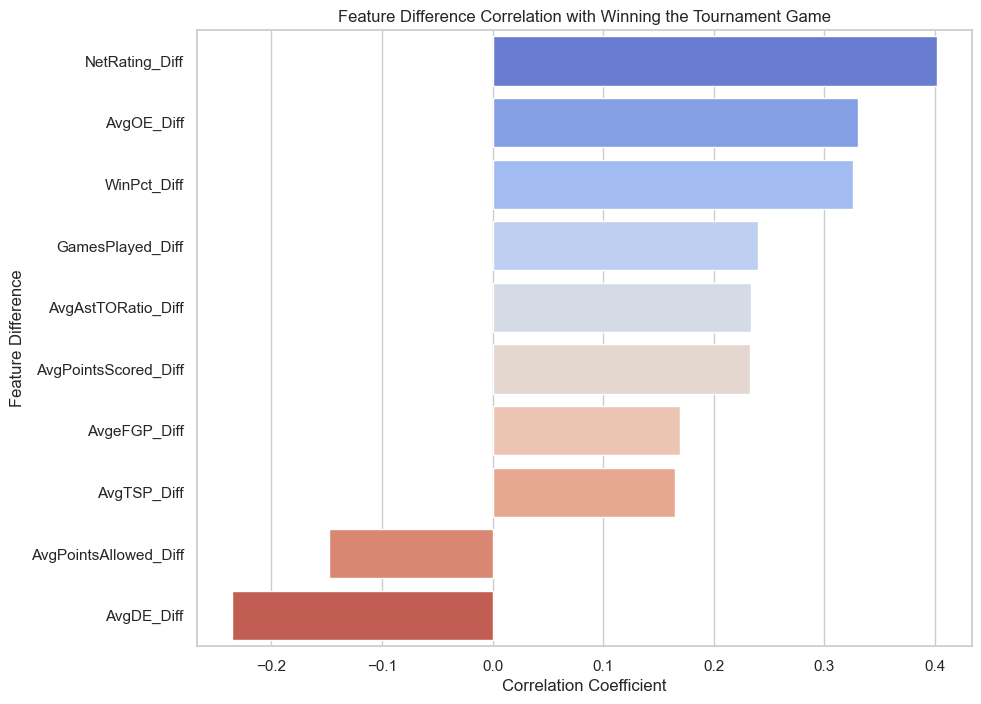

Team1_Wins               1.000000
NetRating_Diff           0.401600
AvgOE_Diff               0.330386
WinPct_Diff              0.326040
GamesPlayed_Diff         0.239733
AvgAstTORatio_Diff       0.233650
AvgPointsScored_Diff     0.232658
AvgeFGP_Diff             0.169892
AvgTSP_Diff              0.164657
AvgPointsAllowed_Diff   -0.148079
AvgDE_Diff              -0.235592
Name: Team1_Wins, dtype: float64


In [5]:
# Load Tournament Compact Results
m_tourney_results = pd.read_csv(f'{DATA_DIR}/MNCAATourneyCompactResults.csv')

# Only keep necessary columns
tourney_matches = m_tourney_results[['Season', 'WTeamID', 'LTeamID']].copy()

# Randomize the match order (so target isn't always "Team 1 wins")
np.random.seed(42)
swap_mask = np.random.rand(len(tourney_matches)) > 0.5

# Create Team1 and Team2 columns symmetrically
tourney_matches['Team1'] = np.where(swap_mask, tourney_matches['LTeamID'], tourney_matches['WTeamID'])
tourney_matches['Team2'] = np.where(swap_mask, tourney_matches['WTeamID'], tourney_matches['LTeamID'])
tourney_matches['Team1_Wins'] = np.where(swap_mask, 0, 1)

# Merge Stats for Team 1
tourney_stats = tourney_matches.merge(team_season_stats, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left')
tourney_stats = tourney_stats.drop('TeamID', axis=1)
tourney_stats = tourney_stats.rename(columns={c: c + '_T1' for c in team_season_stats.columns if c not in ['Season']})

# Merge Stats for Team 2
tourney_stats = tourney_stats.merge(team_season_stats, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left')
tourney_stats = tourney_stats.drop('TeamID', axis=1)
tourney_stats = tourney_stats.rename(columns={c: c + '_T2' for c in team_season_stats.columns if c not in ['Season']})

# Calculate differences
diff_columns = [c.replace('_T1', '') for c in tourney_stats.columns if '_T1' in c]
for c in diff_columns:
    tourney_stats[f'{c}_Diff'] = tourney_stats[f'{c}_T1'] - tourney_stats[f'{c}_T2']

correlation_data = tourney_stats[['Team1_Wins'] + [f'{c}_Diff' for c in diff_columns]]
correlations = correlation_data.corr()['Team1_Wins'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
# Ensure columns exist before plotting
if len(correlations) > 1:
    sns.barplot(x=correlations.values[1:], y=correlations.index[1:], hue=correlations.index[1:], legend=False, palette='coolwarm')
    plt.title('Feature Difference Correlation with Winning the Tournament Game')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Feature Difference')
    plt.show()

# Print strongest correlations
print(correlations)
